# Module 5 — Vol-of-Vol: the second shock

Module 3 shocked the **forward**. This module shocks the **implied volatility** of the
VIX options themselves.

## Why there has to be a second shock

Module 2 showed a VIX option price has three moving inputs: the forward, the implied
vol, and time. When SPX falls, **two** of them move:

- the VIX future rises (Module 3)
- VIX options themselves get more expensive — their implied vol rises too

Shocking only the forward misses the second effect. The model applies both, and always
reports P&L *both ways* so the vol contribution is never hidden.

## The elegant part

**It is the same formula as Module 3, with one sign flipped.** Same three dials, same
envelope fit, same machinery — `volofvol.py` literally calls `fit_response()` from
`response.py`. The only difference is what the data says about the convexity dial.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "vixshock").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
pd.set_option("display.width", 200)

import config
from vixshock.response import load_params, beta_of_tenor
from vixshock.volofvol import load_vov_params

P = load_params()          # the VIX response, from Module 3
V = load_vov_params()      # the vol-of-vol response, this module
print("loaded both fitted responses")

loaded both fitted responses


## Step 1 — one sign, two completely different shapes

The convexity dial `k` controls the shape of the down branch:

- **k > 0** → the response *accelerates*. Bigger drops hurt more than proportionally.
- **k < 0** → the response *saturates*. It rises fast at first, then flattens to a ceiling.
- **k = 0** → a straight line.

Nobody chose the sign. The fit searches within `config.K_BOUNDS` and the data picks.

In [2]:
print("WHAT THE DATA CHOSE:\n")
print(f"  VIX response  k = {P.k:+7.2f}   ->  ACCELERATES  (big drops hurt more than proportionally)")
print(f"  vol-of-vol    k = {V.k:+7.2f}   ->  SATURATES    (rises fast, then plateaus)")
print(f"\n  config.K_BOUNDS = {config.K_BOUNDS}, so either sign was available to both fits.")

print("\n\nTHE PLATEAU, IN NUMBERS")
print("A saturating branch has a hard ceiling: gamma_T / |k| vol points.\n")
rows = []
for T in config.TENORS:
    g = beta_of_tenor(T, V.beta_0, V.lam)
    cap = g / abs(V.k)
    rows.append({"tenor": f"{T}d",
                 "at -5%": round(float(V.dvix(-0.05, T)), 1),
                 "at -10%": round(float(V.dvix(-0.10, T)), 1),
                 "at -20%": round(float(V.dvix(-0.20, T)), 1),
                 "at -40%": round(float(V.dvix(-0.40, T)), 1),
                 "CEILING": round(cap, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nNo matter how far SPX falls, the 30-day vol-of-vol shock cannot exceed ~98 vol points.")
print("By -20% it is already at 87% of that ceiling. The -40% column adds almost nothing.")

WHAT THE DATA CHOSE:

  VIX response  k =   +0.90   ->  ACCELERATES  (big drops hurt more than proportionally)
  vol-of-vol    k =  -10.26   ->  SATURATES    (rises fast, then plateaus)

  config.K_BOUNDS = (-60.0, 5.0), so either sign was available to both fits.


THE PLATEAU, IN NUMBERS
A saturating branch has a hard ceiling: gamma_T / |k| vol points.

tenor  at -5%  at -10%  at -20%  at -40%  CEILING
  30d    39.3     62.8     85.3     96.2     97.9
  60d    32.8     52.4     71.1     80.3     81.6
  90d    27.3     43.7     59.3     67.0     68.1
 120d    22.8     36.4     49.5     55.9     56.8

No matter how far SPX falls, the 30-day vol-of-vol shock cannot exceed ~98 vol points.
By -20% it is already at 87% of that ceiling. The -40% column adds almost nothing.


### Why saturation is the economically right shape

Say this out loud and it sounds obvious: **"VIX-option vol jumps on the first few percent
of a sell-off and then levels off."**

Once the market is already in full panic, VIX options are already priced for chaos.
Another 10% down does not double the uncertainty *about VIX* — it was already maximal.
The forward keeps climbing; the vol of that forward runs out of room.

Contrast Module 3, where the VIX response **accelerates**. Two layers, opposite shapes,
same formula. That is a good thing to point at: the functional form was not forced on
either layer — it nests straight-line, accelerating and saturating, and each layer's
data picked its own.

## Step 2 — see the two shapes side by side

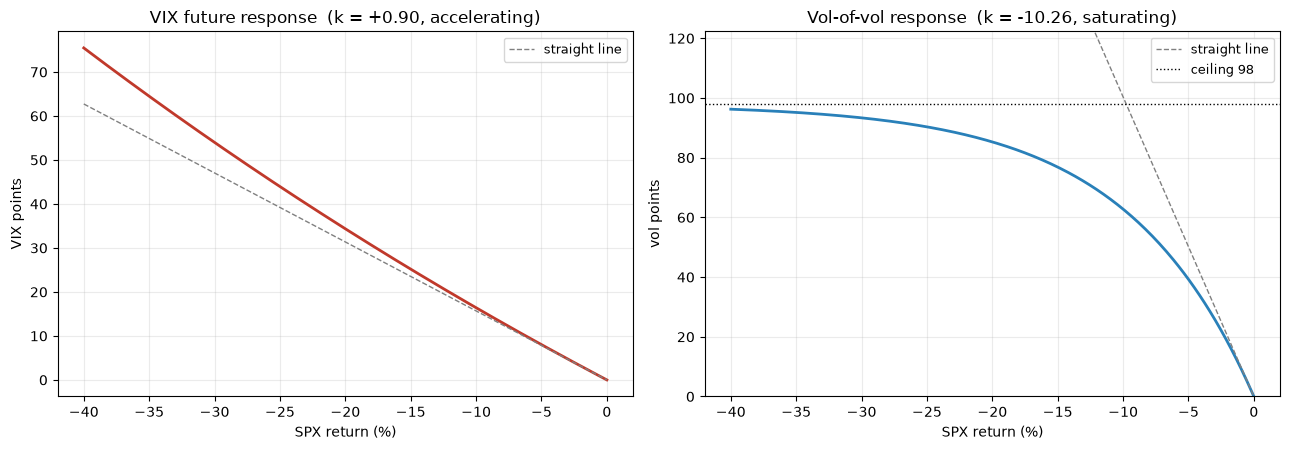

Left: the red line pulls AWAY from the straight line - accelerating.
Right: the blue line falls BELOW it and flattens into the ceiling - saturating.
Same formula. The sign of one dial does all of that.


In [3]:
import matplotlib.pyplot as plt

r = np.linspace(-0.40, 0, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(r * 100, [float(P.dvix(x, 30)) for x in r], lw=2, color="#c0392b")
axes[0].plot(r * 100, [-beta_of_tenor(30, P.beta_0, P.lam) * x for x in r],
             lw=1, ls="--", color="grey", label="straight line")
axes[0].set_title(f"VIX future response  (k = {P.k:+.2f}, accelerating)")
axes[0].set_ylabel("VIX points")

cap = beta_of_tenor(30, V.beta_0, V.lam) / abs(V.k)
axes[1].plot(r * 100, [float(V.dvix(x, 30)) for x in r], lw=2, color="#2980b9")
axes[1].plot(r * 100, [-beta_of_tenor(30, V.beta_0, V.lam) * x for x in r],
             lw=1, ls="--", color="grey", label="straight line")
axes[1].axhline(cap, color="black", lw=1, ls=":", label=f"ceiling {cap:.0f}")
axes[1].set_ylim(0, cap * 1.25)
axes[1].set_title(f"Vol-of-vol response  (k = {V.k:+.2f}, saturating)")
axes[1].set_ylabel("vol points")

for ax in axes:
    ax.set_xlabel("SPX return (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

print("Left: the red line pulls AWAY from the straight line - accelerating.")
print("Right: the blue line falls BELOW it and flattens into the ceiling - saturating.")
print("Same formula. The sign of one dial does all of that.")

## Step 3 — the data, and its honest weakness

This layer has the weakest data in the model. Know it before someone finds it.

There are two possible sources, set by `config.VOV_SOURCE`:

| source | tenors | what it is |
|---|---|---|
| `historical` | 30, 60, 90, 180 | a **frozen** one-time Bloomberg pull in `data/bloomberg_historical/`. Not a live dependency — delete it and the model still runs |
| `vvix` | **30 only** | CBOE's free VVIX index |
| `auto` | — | uses the frozen file if present, else VVIX |

**The VVIX-only path has a real methodological cost.** With one tenor there is no
information about how vol-of-vol fades along the curve, so the code *borrows the VIX
response's tenor-fade dial* and labels the fit accordingly. An honest assumption,
disclosed in the output — but an assumption. Say it before you are asked.

In [4]:
print("THE FIT CURRENTLY IN FORCE\n")
print(V.summary().replace("response function", "vol-of-vol response"))
print(f"\n  method_down says: {V.method_down!r}")
if "assumed" in V.method_down:
    print("  ^ the tenor-fade dial was BORROWED from the VIX response, not fitted.")
else:
    print("  ^ fitted across multiple tenors from the frozen historical file.")

print("\n\nFIT QUALITY - compare with Module 3's numbers\n")
rows = []
for T, v in V.per_tenor.items():
    rows.append({"tenor": f"{T}d",
                 "coverage": f"{v['joint_coverage_down']*100:.1f}%",
                 "R2 envelope (joint)": round(v["joint_r2_env_points"], 3),
                 "R2 envelope (free)": round(v["r2_env_points"], 3),
                 "R2 up branch": round(v["joint_r2_up"], 3)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nThe 30-day point is the WEAKEST fit in the model (compare 0.946 for the VIX")
print("response at the same tenor), and the joint form pulls its beta down materially")
print("from the free per-tenor fit. That is the tenor most positions care about.")

THE FIT CURRENTLY IN FORCE

vol-of-vol response  (down: envelope q=0.95; horizon pooled 1-20d; fit 2006-04-25 -> 2026-09-16, n=69419)
  beta_0 =  1203.23   k = -10.26   lam = 0.181      (down branch)
  beta_up_0 = 301.51              lam_up = 0.344   (up branch)
  implied beta_T:  T30: dn 1003.7 / up 213.8  T60: dn  837.3 / up 151.7  T90: dn  698.5 / up 107.6  T120: dn  582.7 / up  76.3

  method_down says: 'envelope'
  ^ fitted across multiple tenors from the frozen historical file.


FIT QUALITY - compare with Module 3's numbers

tenor coverage  R2 envelope (joint)  R2 envelope (free)  R2 up branch
  30d    89.2%                0.777               0.820         0.172
  60d    93.5%                0.928               0.938         0.152
  90d    96.0%                0.888               0.929         0.128
 180d    95.2%                0.828               0.895         0.048

The 30-day point is the WEAKEST fit in the model (compare 0.946 for the VIX
response at the same tenor), and th

## Step 4 — how much does this layer actually matter?

The forward shock dominates at big shocks, so it is tempting to call the vol layer a
minor correction. **The numbers say otherwise for the shocks you will run most often.**

The model prices each scenario twice — once with the vol held still, once with it
shocked — and reports the difference as `vol_of_vol_effect`. Watch the last column.

In [5]:
from vixshock.pricing import black76
from vixshock import shock as sh

asof, vix_curve, vov_curve, spot = sh.latest_curves()
DTE, K, RATE = 91, 25.0, config.RISK_FREE_RATE
F0, V0, yrs = float(vix_curve(DTE)), float(vov_curve(DTE)), DTE / 365
p0 = float(black76(F0, K, yrs, V0, RATE, True))

print(f"A {DTE}-day {K:.0f}-strike call.  forward {F0:.2f}, vol {V0*100:.1f}%, price {p0:.4f}\n")
rows = []
for s in (-0.05, -0.10, -0.20, -0.30, 0.10, 0.20):
    dF = float(P.dvix(s, DTE))
    dV = float(V.dvix(s, DTE)) / 100
    pf = float(black76(F0 + dF, K, yrs, V0, RATE, True))                    # vol held fixed
    pv = float(black76(F0 + dF, K, yrs, max(V0 + dV, 0.20), RATE, True))    # vol shocked too
    rows.append({"SPX": f"{s:+.0%}", "fwd moves": round(dF, 1), "vol moves": round(dV*100, 1),
                 "price, vol fixed": round(pf, 3), "price, vol shocked": round(pv, 3),
                 "vol-of-vol effect": round(pv - pf, 3),
                 "% of the move": f"{abs(pv-pf)/max(abs(pf-p0),1e-9)*100:.0f}%"})
print(pd.DataFrame(rows).to_string(index=False))

print("\nRead the last column carefully - it is NOT a small correction:")
print("  at  -5%  the vol shock is 58% the size of the forward-only move")
print("  at -10%  it is 36%")
print("  at -20%  it is 13%")
print("\nThe vol layer matters MOST for SMALL shocks, and fades as the forward move")
print("takes over. That is the saturation at work: the vol shock hits its ceiling")
print("early while the forward keeps climbing.")
print("\nSo 'second-order' is wrong for the shocks you will run most often. Anyone")
print("holding implied vol fixed would badly understate a -5% or -10% scenario.")
print("\nOn a LONG call the vol shock ADDS value on the way down (long vega).")
print("For a SHORT position it works against you - the case that matters here.")

A 91-day 25-strike call.  forward 19.17, vol 72.5%, price 1.0475

 SPX  fwd moves  vol moves  price, vol fixed  price, vol shocked  vol-of-vol effect % of the move
 -5%        5.3       27.2             3.277               4.571              1.294           58%
-10%       10.9       43.4             6.924               9.028              2.104           36%
-20%       22.9       59.0            17.240              19.342              2.103           13%
-30%       35.9       64.6            29.847              31.268              1.421            5%
+10%       -3.5      -10.6             0.331               0.174             -0.157           22%
+20%       -6.9      -21.3             0.057               0.003             -0.053            5%

Read the last column carefully - it is NOT a small correction:
  at  -5%  the vol shock is 58% the size of the forward-only move
  at -10%  it is 36%
  at -20%  it is 13%

The vol layer matters MOST for SMALL shocks, and fades as the forward move


## Step 5 — the caveat that matters for far-OTM books

**The vol-of-vol shock is an additive parallel shift.** It adds the same number of vol
points to every position at a given tenor, whatever that position's starting vol is.

For an at-the-money option that is fine. For a far-OTM call carrying a large skew
premium it is questionable — and you should raise it yourself.

In [6]:
dV20 = float(V.dvix(-0.20, 91)) / 100
atm, otm = 0.725, 1.269       # ATM vol vs the vol implied by a 4c 100-strike premium

print(f"The -20% shock adds {dV20*100:+.1f} vol points at 90 days, to EVERY position:\n")
print(f"  an ATM option:      {atm*100:5.1f}%  ->  {(atm+dV20)*100:5.1f}%")
print(f"  a 100-strike call:  {otm*100:5.1f}%  ->  {(otm+dV20)*100:5.1f}%")
print("\nIs 186% plausible for that strike after a 20% crash? Probably too high --")
print("and for a specific reason:")

F_now = float(vix_curve(91))
F_sh = F_now + float(P.dvix(-0.20, 91))
print(f"\n  today      the 100 strike is {100/F_now:.1f}x the forward ({F_now:.1f}) - extreme, big skew")
print(f"  after -20% it is only      {100/F_sh:.1f}x the forward ({F_sh:.1f}) - much less extreme")
print("\nReal skew FLATTENS as the forward rises toward the strike. A parallel shift")
print("keeps the full skew premium intact, so it likely OVERSTATES the shocked vol here.")
print("\nFor a SHORT position that overstates the loss -- conservative, the right way to")
print("err. But state it as an approximation before someone else identifies it.")

The -20% shock adds +59.0 vol points at 90 days, to EVERY position:

  an ATM option:       72.5%  ->  131.5%
  a 100-strike call:  126.9%  ->  185.9%

Is 186% plausible for that strike after a 20% crash? Probably too high --
and for a specific reason:

  today      the 100 strike is 5.2x the forward (19.2) - extreme, big skew
  after -20% it is only      2.4x the forward (42.0) - much less extreme

Real skew FLATTENS as the forward rises toward the strike. A parallel shift
keeps the full skew premium intact, so it likely OVERSTATES the shocked vol here.

For a SHORT position that overstates the loss -- conservative, the right way to
err. But state it as an approximation before someone else identifies it.


---

## What to take away

**What this layer is:** the same three-dial formula as the VIX response, applied to the
implied volatility of VIX options instead of the futures level. `volofvol.py` calls
`fit_response()` from `response.py` — it is genuinely the same code.

**The one difference:** the data chose a *negative* convexity dial, so this branch
**saturates** where the VIX response **accelerates**. Economically: VIX-option vol jumps
on the first few percent of a sell-off and then levels off. The 30-day shock has a hard
ceiling near 98 vol points and is already at 87% of it by −20%.

**Why both shapes from one formula matters:** the functional form nests straight-line,
accelerating and saturating. Neither layer was forced into a shape — each one's data
picked. That is a genuine point in the model's favour.

**It is not a minor correction at the shocks you will run most.** As a share of the
forward-only move, the vol effect is **58% at −5%**, **36% at −10%**, **13% at −20%**.
It matters *most* for small shocks and fades as the forward move takes over — that is
saturation at work. Anyone holding implied vol fixed would badly understate a −5% or
−10% scenario. This is why the model always reports both numbers.

**The weaknesses, all worth conceding first:**

1. **Weakest data in the model.** Either a frozen Bloomberg file (four tenors) or VVIX
   (one tenor). On the VVIX path the tenor-fade dial is *borrowed* from the VIX response
   rather than fitted — disclosed in the output, but an assumption.
2. **Weakest fit in the model.** The 30-day envelope R² is 0.777 joint / 0.820 free,
   against 0.946 for the VIX response at the same tenor — and 30 days is where most
   positions sit. Coverage there is 89.2%, the lowest in either layer.
3. **Additive parallel shift.** The same vol points are added regardless of starting vol.
   Real skew flattens as the forward rises toward the strike, so far-OTM shocked vols are
   likely overstated — conservative for a short position, but an approximation.
4. **Methodology mix** (on the historical path): 30-day is CBOE's VVIX, the rest is
   Bloomberg ATM interpolation. Levels are not comparable across the two; the fit uses
   *changes*, which mitigates it but does bias the tenor-fade estimate.

**Code:** `vixshock/volofvol.py` (~117 lines, most of it data loading). Report section 6.

---

### Questions to test yourself

1. The VIX response accelerates and vol-of-vol saturates. How can both come from the
   same formula, and why is that a point in the model's favour?
2. Explain in one sentence why vol-of-vol plateaus, in market terms.
3. A reviewer asks why you use Bloomberg data if the model is supposed to be
   Bloomberg-free. What do you say?
4. Your book is short far-OTM calls. Is the parallel-shift approximation helping or
   hurting your reported risk?
5. Someone proposes dropping the vol-of-vol layer to simplify the model. Using the
   numbers in Step 4, argue against it.

Next: **Module 6 — running it**: the two entry points, the gates, and how to read a report.